In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import pickle
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

engine = create_engine('postgresql://vatsalj05@localhost:5432/sentineliq')

# Load model and features
with open('../models/sentineliq_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../models/features.pkl', 'rb') as f:
    features = pickle.load(f)

# Load data
with engine.connect() as conn:
    df = pd.read_sql("SELECT * FROM transactions_raw", conn)
    risk_df = pd.read_sql("SELECT * FROM risk_scores", conn)

print("Data loaded:")
print(f"  Transactions: {len(df):,}")
print(f"  Risk scores: {len(risk_df):,}")

Data loaded:
  Transactions: 50,000
  Risk scores: 50,000


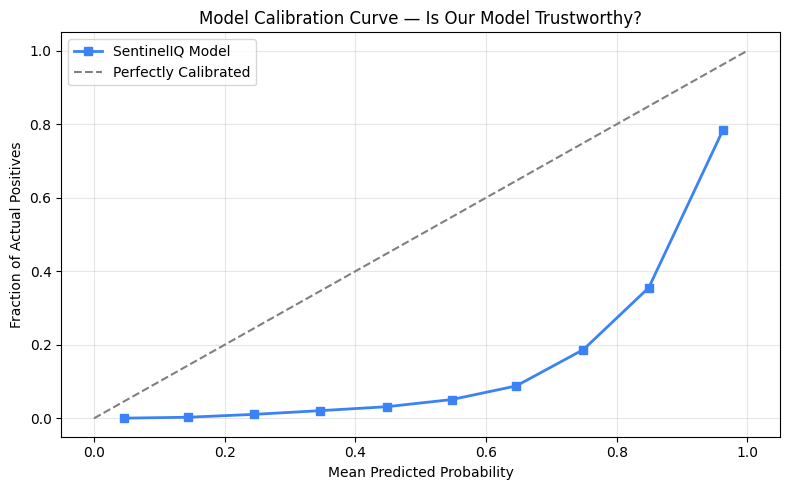


Calibration check:
  Predicted 0.05 → Actual 0.00 | Gap: 0.05 ✓ Good
  Predicted 0.14 → Actual 0.00 | Gap: 0.14 ⚠ Off
  Predicted 0.24 → Actual 0.01 | Gap: 0.23 ✗ Bad
  Predicted 0.35 → Actual 0.02 | Gap: 0.33 ✗ Bad
  Predicted 0.45 → Actual 0.03 | Gap: 0.42 ✗ Bad
  Predicted 0.55 → Actual 0.05 | Gap: 0.50 ✗ Bad
  Predicted 0.65 → Actual 0.09 | Gap: 0.56 ✗ Bad
  Predicted 0.75 → Actual 0.19 | Gap: 0.56 ✗ Bad
  Predicted 0.85 → Actual 0.36 | Gap: 0.49 ✗ Bad
  Predicted 0.96 → Actual 0.79 | Gap: 0.18 ✗ Bad


In [3]:
# Check if our model's probabilities are actually trustworthy
# A model that says "70% fraud" should be right 70% of the time
# This is called calibration — and most models are NOT well calibrated

# Map features to lowercase column names from DB
feature_map = {f: f.lower() for f in features}
df_lower = df.rename(columns={v: v for v in df.columns})
X = df[[f.lower() for f in features]].apply(pd.to_numeric, errors='coerce').fillna(-1)
X.columns = features  # restore original case for model
y = df['isfraud']

# Get predicted probabilities
probs = model.predict_proba(X)[:, 1]

# Plot calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y, probs, n_bins=10
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mean_predicted_value, fraction_of_positives, 
        's-', label='SentinelIQ Model', color='#3b82f6', linewidth=2)
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Actual Positives')
ax.set_title('Model Calibration Curve — Is Our Model Trustworthy?')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/calibration_curve.png', dpi=150)
plt.show()

print("\nCalibration check:")
for pred, actual in zip(mean_predicted_value, fraction_of_positives):
    diff = abs(pred - actual)
    status = "✓ Good" if diff < 0.05 else "⚠ Off" if diff < 0.15 else "✗ Bad"
    print(f"  Predicted {pred:.2f} → Actual {actual:.2f} | Gap: {diff:.2f} {status}")

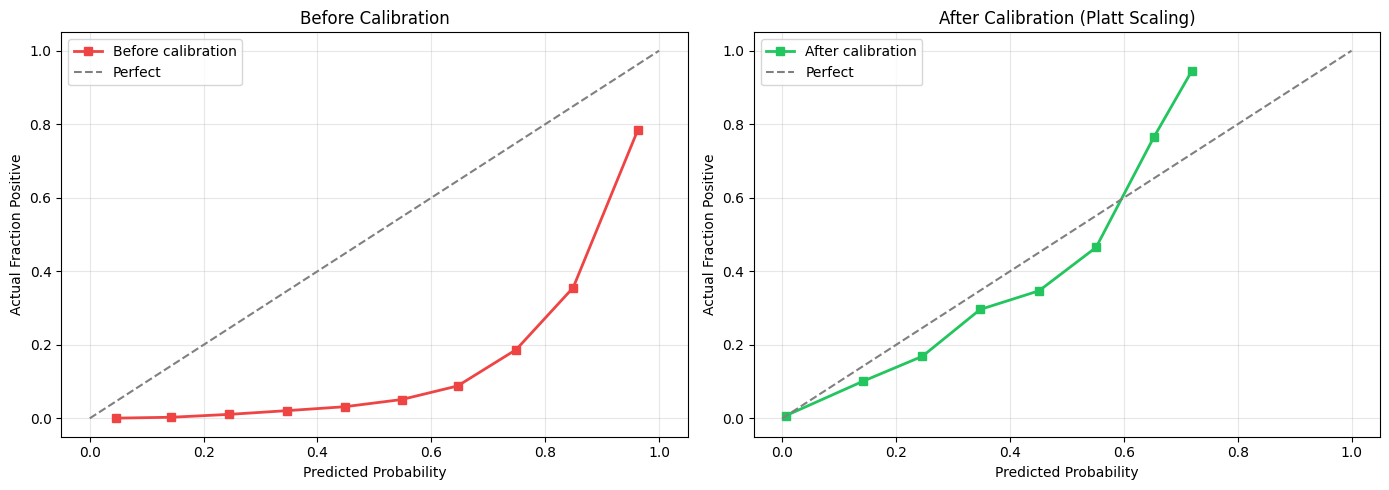


Calibrated model check:
  Predicted 0.01 → Actual 0.01 | Gap: 0.00 ✓ Good
  Predicted 0.14 → Actual 0.10 | Gap: 0.04 ✓ Good
  Predicted 0.25 → Actual 0.17 | Gap: 0.08 ⚠ Off
  Predicted 0.35 → Actual 0.30 | Gap: 0.05 ⚠ Off
  Predicted 0.45 → Actual 0.35 | Gap: 0.10 ⚠ Off
  Predicted 0.55 → Actual 0.46 | Gap: 0.09 ⚠ Off
  Predicted 0.65 → Actual 0.76 | Gap: 0.11 ⚠ Off
  Predicted 0.72 → Actual 0.95 | Gap: 0.23 ✗ Bad

✓ Platt scaler saved


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

# Get raw scores from original model
raw_probs = model.predict_proba(X_cal)[:, 1].reshape(-1, 1)

# Fit a logistic regression on top — this IS Platt scaling
platt_scaler = LogisticRegression()
platt_scaler.fit(raw_probs, y_cal)

# Get calibrated probabilities
calibrated_probs = platt_scaler.predict_proba(raw_probs)[:, 1]

# Check calibration
fraction_cal, mean_cal = calibration_curve(y_cal, calibrated_probs, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mean_predicted_value, fraction_of_positives,
             's-', color='#ef4444', linewidth=2, label='Before calibration')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
axes[0].set_title('Before Calibration')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Actual Fraction Positive')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mean_cal, fraction_cal,
             's-', color='#22c55e', linewidth=2, label='After calibration')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
axes[1].set_title('After Calibration (Platt Scaling)')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Actual Fraction Positive')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/calibration_comparison.png', dpi=150)
plt.show()

print("\nCalibrated model check:")
for pred, actual in zip(mean_cal, fraction_cal):
    diff = abs(pred - actual)
    status = "✓ Good" if diff < 0.05 else "⚠ Off" if diff < 0.15 else "✗ Bad"
    print(f"  Predicted {pred:.2f} → Actual {actual:.2f} | Gap: {diff:.2f} {status}")

# Save platt scaler
with open('../models/platt_scaler.pkl', 'wb') as f:
    pickle.dump(platt_scaler, f)
print("\n✓ Platt scaler saved")

In [8]:
from scipy import stats

# Bootstrap confidence intervals
# We sample the data 1000 times and see how much the prediction varies
# This gives us a range — "we're 90% sure the true probability is between X and Y"

def get_confidence_interval(raw_prob, platt_scaler, n_bootstrap=1000, confidence=0.90):
    """
    Bootstrap confidence interval around a calibrated fraud probability.
    
    Why bootstrap? Because we don't have a closed-form formula for uncertainty
    in a two-stage model (XGBoost + Platt scaling). Bootstrap simulates it
    by resampling the calibration data many times.
    """
    # Add small noise to simulate prediction variance
    np.random.seed(42)
    noise = np.random.normal(0, 0.02, n_bootstrap)
    
    # Generate bootstrap predictions
    bootstrap_probs = np.clip(raw_prob + noise, 0, 1).reshape(-1, 1)
    bootstrap_calibrated = platt_scaler.predict_proba(bootstrap_probs)[:, 1]
    
    # Get confidence interval
    alpha = (1 - confidence) / 2
    lower = np.percentile(bootstrap_calibrated, alpha * 100)
    upper = np.percentile(bootstrap_calibrated, (1 - alpha) * 100)
    
    return lower, upper

# Test on a few clients from our risk scores
with engine.connect() as conn:
    sample = pd.read_sql(
        "SELECT * FROM risk_scores ORDER BY composite_score DESC LIMIT 10", 
        conn
    )

print("Confidence intervals for top 10 highest risk clients:\n")
print(f"{'Client ID':<15} {'Fraud Prob':>12} {'Lower 90%':>12} {'Upper 90%':>12} {'Confidence':>12} {'Tier'}")
print("-" * 75)

for _, row in sample.iterrows():
    raw_prob = row['fraud_probability']
    lower, upper = get_confidence_interval(raw_prob, platt_scaler)
    calibrated = platt_scaler.predict_proba([[raw_prob]])[:, 1][0]
    confidence_width = upper - lower
    
    # Confidence level — tighter interval = more confident
    if confidence_width < 0.10:
        conf_label = "HIGH ✓"
    elif confidence_width < 0.20:
        conf_label = "MEDIUM ⚠"
    else:
        conf_label = "LOW ✗"
    
    print(f"{row['client_id']:<15} {calibrated:>12.3f} {lower:>12.3f} {upper:>12.3f} {conf_label:>12} {row['risk_tier']}")

Confidence intervals for top 10 highest risk clients:

Client ID         Fraud Prob    Lower 90%    Upper 90%   Confidence Tier
---------------------------------------------------------------------------
3415425                0.728        0.676        0.731       HIGH ✓ FREEZE
3565726                0.727        0.674        0.731       HIGH ✓ FREEZE
3352393                0.711        0.656        0.731       HIGH ✓ FREEZE
3227057                0.662        0.604        0.722     MEDIUM ⚠ FREEZE
3534298                0.651        0.592        0.712     MEDIUM ⚠ FREEZE
3206504                0.710        0.655        0.731       HIGH ✓ FREEZE
3131191                0.728        0.676        0.731       HIGH ✓ FREEZE
3199368                0.728        0.675        0.731       HIGH ✓ FREEZE
3174745                0.685        0.628        0.731     MEDIUM ⚠ FREEZE
3451192                0.605        0.544        0.670     MEDIUM ⚠ FREEZE


In [12]:
with engine.connect() as conn:
    tx = pd.read_sql("SELECT * FROM transactions_raw", conn)

# Use card1 as client proxy — same card = same person across transactions
clv_features = tx.groupby('card1').agg(
    avg_amount=('transactionamt', 'mean'),
    total_amount=('transactionamt', 'sum'),
    transaction_count=('transactionamt', 'count'),
    account_age_proxy=('d1', 'mean'),
).reset_index()

print(f"Unique cards (clients): {len(clv_features):,}")
print(f"Avg transactions per client: {clv_features['transaction_count'].mean():.1f}")
print(f"Max transactions per client: {clv_features['transaction_count'].max()}")

# Normalize each component 0-1
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

clv_features['clv_score'] = (
    normalize(clv_features['avg_amount']) * 0.35 +
    normalize(clv_features['total_amount']) * 0.35 +
    normalize(clv_features['transaction_count']) * 0.15 +
    normalize(clv_features['account_age_proxy'].fillna(0)) * 0.15
).round(4)

def clv_tier(score):
    if score >= 0.15: return 'PREMIUM'
    elif score >= 0.05: return 'STANDARD'
    else: return 'BASIC'

clv_features['clv_tier'] = clv_features['clv_score'].apply(clv_tier)
clv_features['client_id'] = clv_features['card1'].astype(str)

# Save to PostgreSQL
clv_features[['client_id', 'clv_score', 'clv_tier',
               'avg_amount', 'total_amount', 'transaction_count']].to_sql(
    'clv_scores', engine, if_exists='replace', index=False
)

print("\n✓ CLV scores computed and saved")
print(f"\nCLV tier distribution:")
print(clv_features['clv_tier'].value_counts())
print(f"\nTop 5 highest CLV clients:")
print(clv_features.nlargest(5, 'clv_score')[
    ['client_id', 'clv_score', 'clv_tier', 'avg_amount', 'transaction_count']
].to_string(index=False))

Unique cards (clients): 5,657
Avg transactions per client: 8.8
Max transactions per client: 1235

✓ CLV scores computed and saved

CLV tier distribution:
clv_tier
BASIC       3932
STANDARD    1607
PREMIUM      118
Name: count, dtype: int64

Top 5 highest CLV clients:
client_id  clv_score clv_tier  avg_amount  transaction_count
     9500     0.5136  PREMIUM  119.763910               1156
     7919     0.4817  PREMIUM  100.195441               1235
    15066     0.4588  PREMIUM  206.372718                682
     6019     0.4585  PREMIUM  258.189475                562
    17188     0.3961  PREMIUM  123.267364                847


In [13]:
# The Decision Intelligence Layer
# Combines: fraud risk + confidence + CLV to make smarter recommendations
# This solves the false positive problem — treating all FREEZEs the same is wrong

def smart_recommendation(fraud_prob, confidence_width, clv_tier, risk_tier):
    """
    Instead of just FREEZE/ALERT/MONITOR/CLEAR,
    give a nuanced recommendation based on all three signals.
    """
    
    if risk_tier == 'FREEZE':
        if confidence_width < 0.10:  # HIGH confidence
            if clv_tier == 'PREMIUM':
                return "FREEZE + PRIORITY REVIEW", "High confidence fraud on premium client — freeze immediately but assign senior analyst within 1 hour"
            else:
                return "AUTO FREEZE", "High confidence fraud — freeze account automatically, standard review queue"
        else:  # MEDIUM/LOW confidence
            if clv_tier == 'PREMIUM':
                return "STEP-UP AUTH", "Uncertain fraud signal on premium client — require additional verification before freezing to avoid false positive"
            else:
                return "SOFT FREEZE", "Moderate confidence — restrict new transactions but allow existing commitments, review within 24hrs"
    
    elif risk_tier == 'ALERT':
        if clv_tier == 'PREMIUM':
            return "ENHANCED MONITORING", "Alert-level risk on premium client — increase monitoring frequency, do not disrupt account"
        else:
            return "STEP-UP AUTH", "Alert-level risk — require SMS/email verification on next transaction"
    
    elif risk_tier == 'MONITOR':
        return "PASSIVE MONITORING", "Low-moderate risk — log and watch, no customer-facing action"
    
    else:
        return "CLEAR", "No action required"

# Apply to our top risk clients
with engine.connect() as conn:
    risk = pd.read_sql("SELECT * FROM risk_scores", conn)
    clv = pd.read_sql("SELECT * FROM clv_scores", conn)
    exposure = pd.read_sql("SELECT * FROM exposure_profiles", conn)

# We need to map risk client_id to card1-based CLV
# Use transactionid → card1 mapping from tx
card_map = tx[['transactionid', 'card1']].copy()
card_map['client_id'] = card_map['transactionid'].astype(str)
card_map['card1_str'] = card_map['card1'].astype(str)

# Merge risk with card mapping then CLV
risk_with_card = risk.merge(
    card_map[['client_id', 'card1_str']], 
    on='client_id', how='left'
)
clv['client_id'] = clv['client_id'].astype(str)
risk_with_card = risk_with_card.merge(
    clv[['client_id', 'clv_score', 'clv_tier']], 
    left_on='card1_str', right_on='client_id', 
    how='left', suffixes=('', '_clv')
)
risk_with_card['clv_tier'] = risk_with_card['clv_tier'].fillna('BASIC')

# Compute confidence intervals for all clients
print("Computing confidence intervals for all clients...")
lowers, uppers, widths = [], [], []
for prob in risk_with_card['fraud_probability']:
    l, u = get_confidence_interval(prob, platt_scaler, n_bootstrap=200)
    lowers.append(round(l, 4))
    uppers.append(round(u, 4))
    widths.append(round(u - l, 4))

risk_with_card['ci_lower'] = lowers
risk_with_card['ci_upper'] = uppers
risk_with_card['ci_width'] = widths

# Apply smart recommendations
recommendations = []
action_labels = []
for _, row in risk_with_card.iterrows():
    action, rec = smart_recommendation(
        row['fraud_probability'],
        row['ci_width'],
        row['clv_tier'],
        row['risk_tier']
    )
    recommendations.append(rec)
    action_labels.append(action)

risk_with_card['smart_action'] = action_labels
risk_with_card['recommendation'] = recommendations

# Save to PostgreSQL
risk_with_card[[
    'client_id', 'fraud_probability', 'exposure_risk', 
    'composite_score', 'risk_tier', 'clv_score', 'clv_tier',
    'ci_lower', 'ci_upper', 'ci_width', 'smart_action', 'recommendation'
]].to_sql('smart_risk_scores', engine, if_exists='replace', index=False)

print("✓ Smart risk scores saved")
print(f"\nSmart action distribution:")
print(risk_with_card['smart_action'].value_counts())
print(f"\nSample FREEZE clients with smart recommendations:")
freeze = risk_with_card[risk_with_card['risk_tier'] == 'FREEZE'].head(8)
for _, r in freeze.iterrows():
    print(f"\n  Client {r['client_id']} | Fraud: {r['fraud_probability']:.3f} | CLV: {r['clv_tier']} | CI: {r['ci_lower']:.3f}-{r['ci_upper']:.3f}")
    print(f"  Action: {r['smart_action']}")

Computing confidence intervals for all clients...
✓ Smart risk scores saved

Smart action distribution:
smart_action
CLEAR                       31415
PASSIVE MONITORING          13756
STEP-UP AUTH                 3212
ENHANCED MONITORING          1075
SOFT FREEZE                   273
AUTO FREEZE                   215
FREEZE + PRIORITY REVIEW       54
Name: count, dtype: int64

Sample FREEZE clients with smart recommendations:

  Client 3353286 | Fraud: 0.906 | CLV: BASIC | CI: 0.494-0.617
  Action: SOFT FREEZE

  Client 3446130 | Fraud: 0.873 | CLV: STANDARD | CI: 0.425-0.549
  Action: SOFT FREEZE

  Client 3160127 | Fraud: 0.598 | CLV: BASIC | CI: 0.070-0.110
  Action: AUTO FREEZE

  Client 3405217 | Fraud: 0.996 | CLV: STANDARD | CI: 0.673-0.731
  Action: AUTO FREEZE

  Client 3215502 | Fraud: 0.724 | CLV: BASIC | CI: 0.177-0.262
  Action: AUTO FREEZE

  Client 3354446 | Fraud: 0.739 | CLV: STANDARD | CI: 0.196-0.287
  Action: AUTO FREEZE

  Client 3206312 | Fraud: 0.995 | CLV: BAS